In [ ]:
# RFM customer segmentation and clustering models - RFM stands for Recency, Frequency, and Monetary value. 
# It is a data-driven method used to segment customers based on their past purchasing behavior in order to identify a company's most valuable buyers

In [1]:
#Environment Setup & Data Aggregation
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Paths
BASE_DIR = os.path.dirname(os.path.abspath(""))
DB_PATH = os.path.join(BASE_DIR, "data-package", "database", "afilearn_commerce_master.db")

# Load Production Cleaned Tables
conn = sqlite3.connect(DB_PATH)
df_orders = pd.read_sql_query("SELECT order_id, customer_id, order_purchase_timestamp FROM prod_orders_cleaned;", conn)
df_items = pd.read_sql_query("SELECT order_id, price FROM prod_items_cleaned;", conn)
conn.close()

# Merge Orders and Items
df_merged = pd.merge(df_orders, df_items, on="order_id", how="inner")
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])

# Define reference point for Recency calculation (1 day after latest purchase)
max_date = df_merged['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Engineer Customer RFM Metrics
rfm = df_merged.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (max_date - x.max()).days,  # Recency
    'order_id': 'count',                                              # Frequency
    'price': 'sum'                                                    # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']
print(f"✔ RFM Feature Matrix Constructed for {len(rfm):,} unique customer profiles.")
rfm.head()

✔ RFM Feature Matrix Constructed for 96,476 unique customer profiles.


,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,89.80
1,000161a058600d5901f007fab4c27140,410,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,548,1,179.99
3,0002414f95344307404f0ace7a26f1d5,379,1,149.90
4,000379cdec625522490c315e70c7a9fb,150,1,93.00


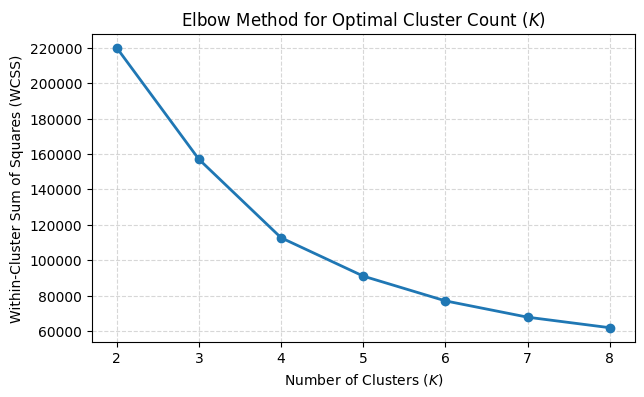

In [2]:
#Feature Scaling & Optimal $K$ Selection (Elbow Method & Silhouette Score)
# Standardize RFM parameters for distance-based clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Determine Optimal K using Inertia (Elbow Method)
wcss = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, marker='o', linewidth=2, color='#1f77b4')
plt.title("Elbow Method for Optimal Cluster Count ($K$)", fontsize=12)
plt.xlabel("Number of Clusters ($K$)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.grid(True, linestyle="--", alpha=0.5)

# Save visual artifact
elbow_path = os.path.join(BASE_DIR, "dashboards", "screenshots", "kmeans_elbow_curve.png")
plt.savefig(elbow_path, bbox_inches='tight', dpi=300)
plt.show()

In [11]:
#Train K-Means Classifier & Generate Cluster Profiles
# Set K = 3 based on elbow inflection point
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

# Calculate Cluster Centroid Averages
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'Customer Count'}).reset_index()

# Map Descriptive Segment Labels
cluster_labels = {
    0: "At-Risk / Lapsed Spenders",
    1: "Recent Low-Value Buyers",
    2: "High-Value Loyalists"
}
cluster_summary['Segment Persona'] = cluster_summary['Cluster'].map(cluster_labels)

print("=== K-MEANS CUSTOMER CLUSTER PROFILES ===")
display(cluster_summary)

# Save your RFM dataframe with cluster labels to CSV
cluster_summary.to_csv("cluster_summary.csv", index=False)

=== K-MEANS CUSTOMER CLUSTER PROFILES ===


,Cluster,Recency,Frequency,Monetary,Customer Count,Segment Persona
0,0,129.960344,1.064708,100.726740,51493,At-Risk / Lapsed Spenders
1,1,390.398571,1.071104,101.570006,38071,Recent Low-Value Buyers
2,2,233.512008,2.111256,518.945013,6912,High-Value Loyalists


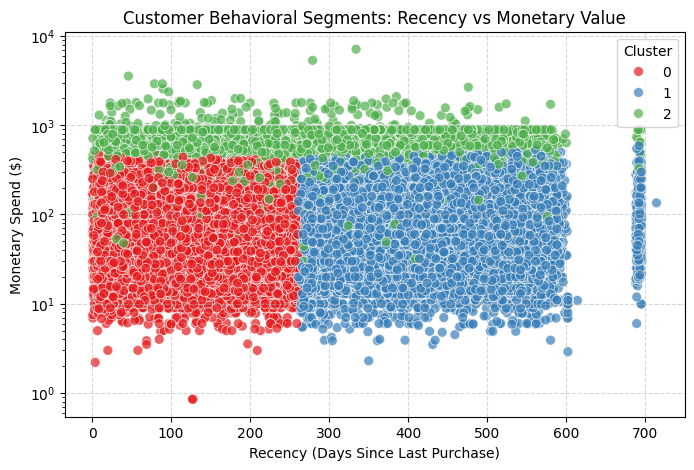

In [4]:
#Cluster Distribution Visualization
# Plot Scatter of Recency vs Monetary across Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm, 
    x='Recency', 
    y='Monetary', 
    hue='Cluster', 
    palette='Set1', 
    alpha=0.7, 
    s=50
)
plt.title("Customer Behavioral Segments: Recency vs Monetary Value", fontsize=12)
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Monetary Spend ($)")
plt.yscale('log') # Log scale handles monetary variance gracefully
plt.grid(True, linestyle="--", alpha=0.5)

# Save Cluster Visual
cluster_plot_path = os.path.join(BASE_DIR, "dashboards", "screenshots", "kmeans_customer_clusters.png")
plt.savefig(cluster_plot_path, bbox_inches='tight', dpi=300)
plt.show()

In [10]:
#Print the Cluster Summary Metrics Table
# Calculate mean & median metrics per cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'count']
}).round(2)

# Rename count column for clarity
cluster_profile.columns = ['_'.join(col).strip() for col in cluster_profile.columns]
cluster_profile = cluster_profile.rename(columns={'Monetary_count': 'Customer_Count'})

print("===  K-MEANS CUSTOMER CLUSTER PROFILES ===")
display(cluster_profile)


===  K-MEANS CUSTOMER CLUSTER PROFILES ===


,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median,Customer_Count
Cluster,,,,,,,
0,290.56,272.0,1.00,1.0,123.25,79.98,68748
1,247.06,227.0,2.44,2.0,202.58,137.80,9387
2,47.66,43.0,1.01,1.0,123.52,79.90,18341


In [7]:
# 1. Apply log transformation to handle right skewness
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# 2. Scale log-transformed features
scaler = StandardScaler()
rfm_scaled_log = scaler.fit_transform(rfm_log)

# 3. Fit K-Means on log-scaled data
kmeans_log = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_log.fit_predict(rfm_scaled_log)

In [8]:
# Save your RFM dataframe with cluster labels to CSV
rfm.to_csv("rfm_clusters.csv", index=False)